# **TRANSFORMING TIME SERIES INTO IMAGES** 

## **1. INTRODUCTION**

The use of Convolutional Neural Networks has become the state-of-the-art approach in various image recognition, computer vision, and speech recognition tasks. This is due to their success in tackling complex problems thanks to their ability to extract relevant information from image-like data structures from certain location-invariance assumptions and weight sharing (See Module 2 of this course).

In the next two modules of this course, we will describe the main Deep Learning models that are used in time series prediction problems (Recurrent Neural Networks among other architectures). But before describing those concepts, it is worth mentioning that there are useful methodologies that allow us to transform time series information into images. Those image versions of time series can then be used as inputs to CNNs that allow us to predict the labels associated to each time series.

Transforming time series into images may turn out to be more effective than resorting to Deep Learning time series models due to two reasons. First, CNNs usually have better behavior while training. Second, we can exploit complex pre-trained CNN architectures, which are not readily available for explicit time series architectures.

In this notebook, we implement the Gramian Angular Field (GAF) methodology that we described in Lesson 3, and illustrate its outcome for a general financial time series. In the previous Lesson, we showed a straightforward coding implementation in Python for GAF. In this notebook, we are going to make use of the "pyts" library, which we load below and that includes a readily available class that performs the GAF transformation.

In [1]:
import matplotlib.pyplot as plt
from pyts.image import GramianAngularField

First, we show for a sample open-source dataset, [GunPoint](http://timeseriesclassification.com/description.php?Dataset=GunPoint), how GAF makes the transformations of time series. The information of this dataset, created for computer vision tasks, provides information about the location of an actor's hands in a sequence where the actor draws a gun (or pretends to draw a gun). The images are represented from a side view. Please, follow the previous link if you are further interested in learning about this dataset.

When we load the dataset, we obtain an two-dimensional array where, out of the 50 rows, each row contains information of a time series with 150 observations. Each time series is "contiguous" to each other, by shifting one time period the observations of the previous sequence. This means that the second row contains the same time series than the first row, except for the first and last observations. The first observation in the second row is the second observation of the first row, the second observation in the second row is the third observation of the first row and so on... 

Formally, consider a time series with realizations $\{x_1, x_2,...,x_K\}$. We can split the time series into sequences of $T$ observations $\{x_t, x_{t+1}, x_{t+2},...,x_{t+T}\}$, for $t\in[1,K-T]$. Then, we form the array $X$ that stacks each of these sequences:

$$
X = \begin{pmatrix}
    x_1 & x_2 & \cdots & x_T \\
    x_2 & x_3 & \cdots & x_{T+1} \\
    x_3 & x_4 & \cdots & x_{T+2} \\
    \vdots & \vdots & \ddots & \vdots \\
    x_{K-T} & x_{K-T+1} & \cdots & x_{K}  
    \end{pmatrix}
$$

In [2]:
from pyts.datasets import load_gunpoint

X, _, _, _ = load_gunpoint(return_X_y=True)
# Check the shape of the array
print(X.shape)
# Print the first 10 observations of the first two rows
# Check that both sequences are contiguous to each other
print(X[0, 0:10])
print(X[0, 1:11])

(50, 150)
[-0.6478854  -0.64199155 -0.63818632 -0.63825875 -0.63834515 -0.63869741
 -0.64304876 -0.64376789 -0.64504991 -0.64711823]
[-0.64199155 -0.63818632 -0.63825875 -0.63834515 -0.63869741 -0.64304876
 -0.64376789 -0.64504991 -0.64711823 -0.64915334]


Now we transform each time series using the Gramian Angular Field. Recall that the transformation involves, first, a Min-Max transformation of each time series that rescales the information to the [-1,1] interval. Second, we compute the polar coordinates, importantly the term $\phi_t=\arccos{(\widetilde{x}_t)}$, for each observation of the scaled time series. Finally, we build the Gram-like matrix, for each time series:

$$
    G = \begin{pmatrix}
           \cos{(\phi_1 + \phi_1)} & \cos{(\phi_1 + \phi_2)} &  \cdots & \cos{(\phi_1 + \phi_T)}  \\
           \cos{(\phi_2 + \phi_1)} & \cos{(\phi_2 + \phi_2)} &  \cdots & \cos{(\phi_2 + \phi_T)} \\
           \vdots & \vdots & \ddots & \vdots \\
           \cos{(\phi_T + \phi_1)} & \cos{(\phi_T + \phi_2)} &  \cdots & \cos{(\phi_T + \phi_T)} \\
        \end{pmatrix}
$$

(150, 150)
(150, 150)


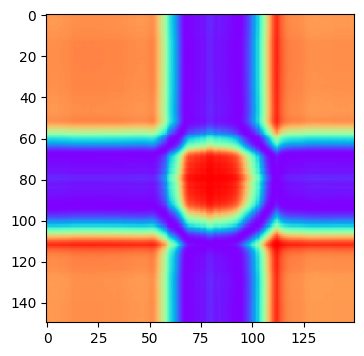

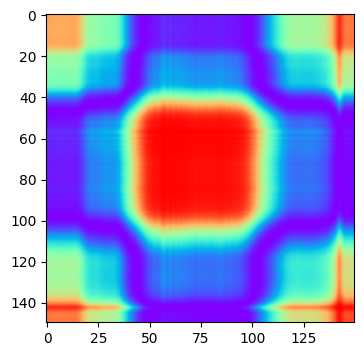

In [3]:
transformer = GramianAngularField()
X_new = transformer.transform(X)
# Show the results for the first time series
plt.figure(figsize=(4, 4))
plt.imshow(X_new[0], cmap="rainbow")
print(X_new[0].shape)
# Show the results for the 10th time series
plt.figure(figsize=(4, 4))
plt.imshow(X_new[9], cmap="rainbow")
print(X_new[9].shape)

The image version of the dataset can then be used to train a convolutional neural network designed to learn from an image if a person, from a side view, is drawing a gun or not.

## **3. GAF FOR A FINANCIAL TIME SERIES**

Now, let's perform the same task for a financial time series. We are going to use daily information about the close price of the ETF QQQ that tracks the Nasdaq index. We use more than 20 years of information.

In [4]:
import numpy as np
import pandas as pd

# Read the CSV file
file_path = 'QQQ.csv'
df = pd.read_csv(file_path, delimiter=';', decimal=',', parse_dates=['Date'], date_format='%m/%d/%y')
df = df.sort_values('Date')
df = df.set_index('Date')

# Rename '% Return' column to 'Ret'
df = df.rename(columns={'% Return': 'Ret'})

# Define the name variable
name = 'Ret'

# Set 'Date' as index and keep only 'Ret' column
df = df.dropna()

df.head()

,Price,CVol,% Change,Open,Low,High,NAV,Total Return (Gross),Ret,Cumulative Return %
Date,,,,,,,,,,
1999-03-11,51.31,9688600.0,0.49,51.44,50.31,51.73,51.10,51.31,0.49,"0,49"
1999-03-12,50.06,8743600.0,-2.44,51.13,49.66,51.16,50.22,50.06,-2.44,"-1,96"
1999-03-15,51.50,6369000.0,2.87,50.44,49.91,51.56,51.51,51.50,2.87,"0,86"
1999-03-16,51.94,4905800.0,0.85,51.72,51.16,52.16,51.83,51.94,0.85,"1,71"
1999-03-17,51.56,3965000.0,-0.72,51.94,51.41,52.00,51.61,51.56,-0.72,"0,98"


(6548,)


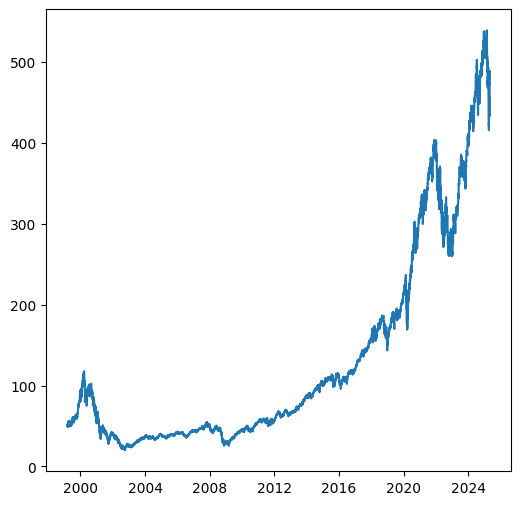

In [5]:
Xdf = df.iloc[:, 0]
print(Xdf.shape)
plt.figure(figsize=(6, 6))
plt.plot(Xdf)

We now build the $X$ matrix that we defined above for the new data, by stacking time series of 30 observations. We illustrate in the figure below how $X$ represents information about 5,781 time series of 30 observations on overlapping intervals as we described above.

(6518, 30)


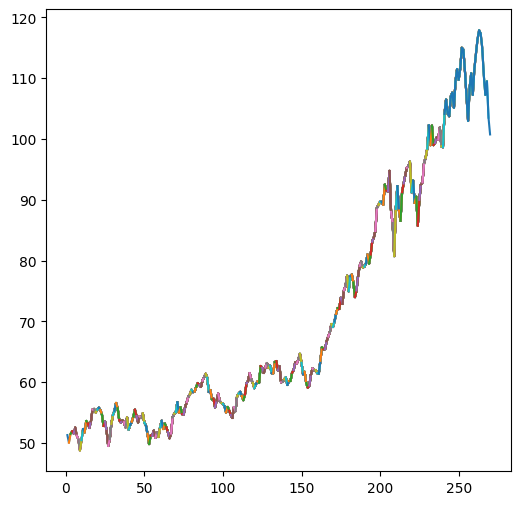

In [6]:
X_train = []
window_size = 30
for i in range(window_size, Xdf.shape[0]):
    X_train.append(Xdf[i - window_size : i])
X_train = np.array(X_train)
print(X_train.shape)
# Define a "window_size"-days interval
days = np.linspace(1, X_train.shape[0], num=X_train.shape[0])
# Plot the overlapping time series
plt.figure(figsize=(6, 6))
for i in range(241):
    plt.plot(days[i : window_size + i], X_train[i, :])

We then apply the GAF transformation and illustrate the outcomes for some observations. Notice how the transformation gives values close to zero to those observations that are close to the average of the time series, while it gives high values to those realizations that are relatively more "extreme" within each time series.

We now have a sample of images, to which we can attach a label, say, whether the price went up or down over the following days, and train a Convolutional Neural Network using the procedures we described in Module 2 and and the first two lessons of Module 3.

In [7]:
transformer = GramianAngularField()
X_train_new = transformer.transform(X_train)
print(X_train_new.shape)

(6518, 30, 30)


(30, 30)


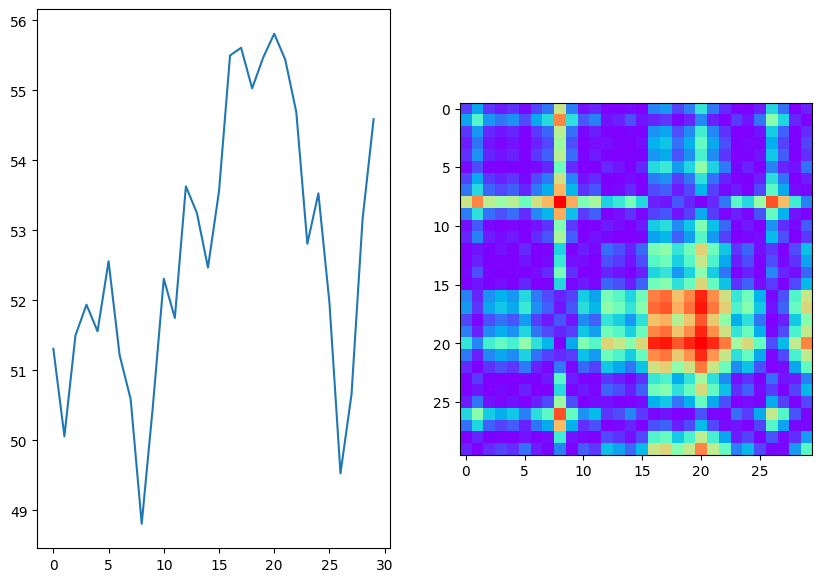

In [8]:
# Show the results for the first time series
fig, ax = plt.subplots(1, 2, figsize=(10, 7), gridspec_kw={"width_ratios": [1, 1]})
ax[0].plot(X_train[0, :])
ax[1].imshow(X_train_new[0], cmap="rainbow")
print(X_train_new[0].shape)

(30, 30)


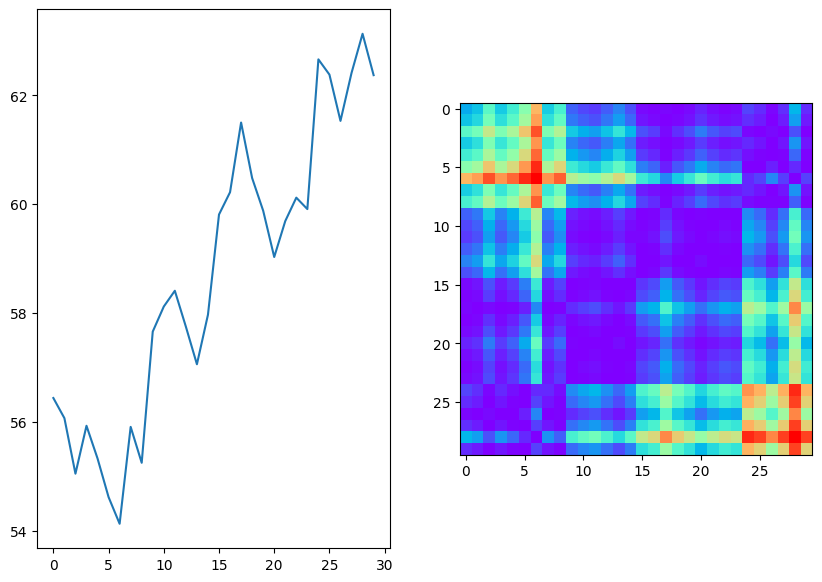

In [9]:
# Show the results for the 100th time series
fig, ax = plt.subplots(1, 2, figsize=(10, 7), gridspec_kw={"width_ratios": [1, 1]})
ax[0].plot(X_train[99, :])
ax[1].imshow(X_train_new[99], cmap="rainbow")
print(X_train_new[99].shape)

## **3. USING THE TRANSFORMED SERIES IN A CNN**

In the blocks of code below, we design a convolutional neural network to predict the evolution of the time series. By now, you should be familiar with this type of structure, so we leave the analysis of the network architecture and its performance to your own judgement.

In [10]:
import tensorflow as tf

2025-05-07 08:17:17.637008: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-07 08:17:17.675082: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-05-07 08:17:18.774566: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [11]:
# Generate the labels: 1 if price goes up after window_size days, 0 otherwise
y_data = []
for i in range(window_size, Xdf.shape[0] - window_size):
    y_data.append(Xdf[i] < Xdf[i + window_size])
y_data = np.array(y_data)
y_data.shape

(6488,)

In [12]:
# Determine the examples to be used as inputs in the model and rescale them to the [0,255] scale
X_data = X_train_new[:-window_size]
for i in range(X_data.shape[0]):
    X_data[i] = (X_data[i] - np.min(X_data[i])) / (
        np.max(X_data[i]) - np.min(X_data[i])
    )
# We could simply write X_data = (X_data + 1)/2
X_data = X_data * 255
X_data.shape

(6488, 30, 30)

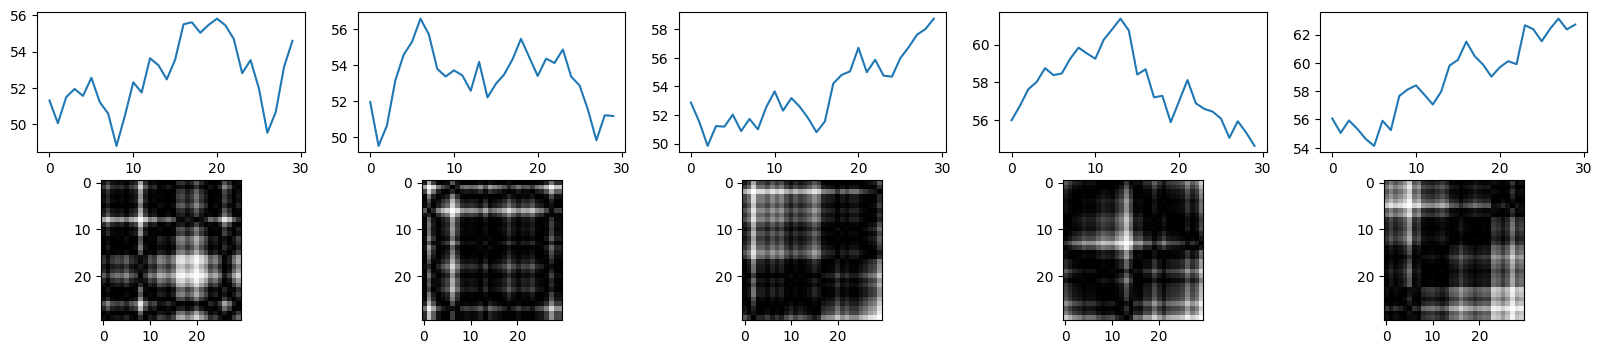

In [13]:
# display several time series and the corresponding images
fig, ax = plt.subplots(2, 5, figsize=(20, 4))
for i in range(0, 125, 25):
    ax[0, int(i / 25)].plot(X_train[i])
for i in range(0, 125, 25):
    ax[1, int(i / 25)].imshow(X_data[i], "gray")

In [14]:
# Split into train and test
train_split = 0.8
y_data_train = y_data[: int(train_split * y_data.shape[0])]
y_data_test = y_data[int(train_split * y_data.shape[0]) :]
X_data_train = X_data[: int(train_split * y_data.shape[0])]
X_data_test = X_data[int(train_split * y_data.shape[0]) :]

In [15]:
model = tf.keras.Sequential()
# Input layer
model.add(tf.keras.layers.InputLayer(input_shape=(30, 30, 1)))
model.add(tf.keras.layers.Conv2D(16, 3, activation="relu"))
model.add(tf.keras.layers.MaxPooling2D(2))
model.add(tf.keras.layers.Conv2D(32, 3, activation="relu"))
model.add(tf.keras.layers.MaxPooling2D(2))
model.add(tf.keras.layers.Conv2D(64, 3, activation="relu"))
model.add(tf.keras.layers.MaxPooling2D(2))
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(1024, activation="relu"))
model.add(tf.keras.layers.Dropout(0.5, seed=1234))
model.add(tf.keras.layers.Dense(1, activation="sigmoid"))

/usr/local/lib/python3.11/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [16]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 12, 12, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         1,025 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 287,489 (1.10 MB)

 Trainable params: 287,489 (1.10 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
model.compile(loss="binary_crossentropy", optimizer="RMSprop", metrics=["accuracy"])
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "model.h5", monitor="val_accuracy", save_best_only=True, mode="auto"
)
class_weight = {0: 1 / (1 - np.mean(y_data_train)), 1: 1.0}
print(class_weight)

{0: 2.694704049844237, 1: 1.0}


In [18]:
model.fit(
    x=X_data_train,
    y=y_data_train,
    epochs=50,
    validation_data=(X_data_test, y_data_test),
    verbose=1,
    callbacks=[checkpoint],
    class_weight=class_weight,
)

Epoch 1/50
157/163 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4493 - loss: 4.6532

163/163 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.4479 - loss: 4.5362 - val_accuracy: 0.3567 - val_loss: 0.7583
Epoch 2/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.3891 - loss: 1.1232 - val_accuracy: 0.3536 - val_loss: 0.7725
Epoch 3/50
161/163 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3793 - loss: 1.0928

163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.3793 - loss: 1.0929 - val_accuracy: 0.4076 - val_loss: 0.7604
Epoch 4/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.3914 - loss: 1.0963 - val_accuracy: 0.3567 - val_loss: 0.8211
Epoch 5/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.3860 - loss: 1.0964 - val_accuracy: 0.3582 - val_loss: 0.7938
Epoch 6/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.3849 - loss: 1.0875 - val_accuracy: 0.3629 - val_loss: 0.8184
Epoch 7/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4156 - loss: 1.0927 - val_accuracy: 0.3659 - val_loss: 0.7806
Epoch 8/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4160 - loss: 1.0913 - val_accuracy: 0.3775 - val_loss: 0.7931
Epoch 9/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4063 - loss: 1.0803 - val_accuracy: 0.3844 - val_loss: 0.7909
Epoch 10/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4369 - loss: 1.0790 - val_accuracy: 0.3636 - val

163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5014 - loss: 1.0182 - val_accuracy: 0.4222 - val_loss: 0.7789
Epoch 15/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5141 - loss: 0.9913 - val_accuracy: 0.3991 - val_loss: 0.8495
Epoch 16/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5258 - loss: 0.9868 - val_accuracy: 0.3852 - val_loss: 0.9068
Epoch 17/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5388 - loss: 0.9629 - val_accuracy: 0.4153 - val_loss: 0.9118
Epoch 18/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5681 - loss: 0.9237 - val_accuracy: 0.3806 - val_loss: 1.0185
Epoch 19/50
158/163 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5816 - loss: 0.9085

163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5816 - loss: 0.9086 - val_accuracy: 0.4638 - val_loss: 0.9787
Epoch 20/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6058 - loss: 0.8744 - val_accuracy: 0.3875 - val_loss: 1.1807
Epoch 21/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6040 - loss: 0.8703 - val_accuracy: 0.4422 - val_loss: 0.9922
Epoch 22/50
161/163 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6270 - loss: 0.8348

163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6270 - loss: 0.8351 - val_accuracy: 0.4723 - val_loss: 1.3726
Epoch 23/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6421 - loss: 0.8420 - val_accuracy: 0.4060 - val_loss: 1.1111
Epoch 24/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6653 - loss: 0.7827 - val_accuracy: 0.4106 - val_loss: 1.2552
Epoch 25/50
160/163 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6644 - loss: 0.7699

163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6644 - loss: 0.7704 - val_accuracy: 0.4823 - val_loss: 1.4214
Epoch 26/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7024 - loss: 0.7693 - val_accuracy: 0.4669 - val_loss: 1.4488
Epoch 27/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7185 - loss: 0.7382 - val_accuracy: 0.4122 - val_loss: 1.4385
Epoch 28/50
159/163 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7241 - loss: 0.6966

163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7241 - loss: 0.6966 - val_accuracy: 0.4938 - val_loss: 1.9754
Epoch 29/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7533 - loss: 0.6517 - val_accuracy: 0.4492 - val_loss: 1.1260
Epoch 30/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7464 - loss: 0.6854 - val_accuracy: 0.4507 - val_loss: 1.5861
Epoch 31/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7698 - loss: 0.6321 - val_accuracy: 0.3690 - val_loss: 1.3616
Epoch 32/50
156/163 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7482 - loss: 0.6376

163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7491 - loss: 0.6366 - val_accuracy: 0.5316 - val_loss: 1.2804
Epoch 33/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7852 - loss: 0.6244 - val_accuracy: 0.4530 - val_loss: 2.2426
Epoch 34/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7879 - loss: 0.5942 - val_accuracy: 0.4707 - val_loss: 1.7875
Epoch 35/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8056 - loss: 0.5323 - val_accuracy: 0.4414 - val_loss: 1.9539
Epoch 36/50
159/163 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8079 - loss: 0.5559

163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8081 - loss: 0.5555 - val_accuracy: 0.5986 - val_loss: 4.9630
Epoch 37/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8286 - loss: 0.5641 - val_accuracy: 0.5670 - val_loss: 2.7113
Epoch 38/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8182 - loss: 0.5301 - val_accuracy: 0.5069 - val_loss: 1.8596
Epoch 39/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8382 - loss: 0.4852 - val_accuracy: 0.4430 - val_loss: 2.3383
Epoch 40/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8498 - loss: 0.4576 - val_accuracy: 0.5331 - val_loss: 2.4713
Epoch 41/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8651 - loss: 0.4176 - val_accuracy: 0.4214 - val_loss: 2.8916
Epoch 42/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8433 - loss: 0.4399 - val_accuracy: 0.4561 - val_loss: 1.9956
Epoch 43/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8592 - loss: 0.4387 - val_accuracy: 0.5424

In [19]:
model = tf.keras.models.load_model("model.h5")
acc = model.evaluate(x=X_data_test, y=y_data_test)
print("Accuracy over validation: {:.2f}%".format(acc[1] * 100))

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6015 - loss: 3.7747
Accuracy over validation: 59.86%


41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
              precision    recall  f1-score   support

       False       0.36      0.16      0.22       463
        True       0.64      0.84      0.73       835

    accuracy                           0.60      1298
   macro avg       0.50      0.50      0.47      1298
weighted avg       0.54      0.60      0.55      1298



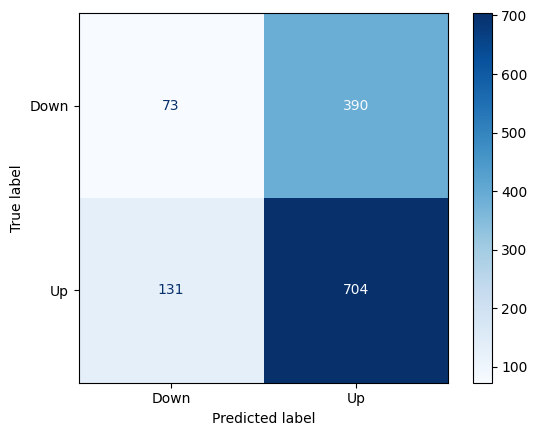

In [20]:
from sklearn import metrics
from sklearn.metrics import classification_report

y_prob = model.predict(X_data_test)
y_pred = np.round(y_prob)
cm = metrics.confusion_matrix(y_data_test, y_pred)
cm = metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Down", "Up"])
cm.plot(values_format="", cmap="Blues")
print(classification_report(y_data_test, y_pred))

## **4. CONCLUSIONS**

In this lesson, we have described the implementation of the GAF transformation to obtain images from time series information. This type of methodology may be effective to enhance our prediction tasks from time series models. Convolutional neural networks have been successful at performing challenging image recognition tasks due to their ability to extract relevant features from images. Thus, it may then be convenient to take advantage of this powerful tool, even when our data is not shown in the form of an image.

In Module 4, we will describe Deep Learning methods that are explicitly designed for the analysis of time series and sequence data.

See you there!<span style='color: transparent; font-size:1%'>All rights reserved WQU WorldQuant University QQQQ</span>

## **TESTS**

Below we show the simple implementation of the GAF algorithm in a few lines of code and compare the results with the class included in the pyts library.

[-0.6     1.      0.744   0.088  -1.      0.5328  0.712   0.984 ]
[2.21429744 0.         0.73175934 1.48268235 3.14159265 1.00889045
 0.77845394 0.17912481]
[[-0.28       -0.6        -0.98094369 -0.84969638  0.6        -0.99667296
  -0.98894357 -0.73293477]
 [-0.6         1.          0.744       0.088      -1.          0.5328
   0.712       0.984     ]
 [-0.98094369  0.744       0.107072   -0.6001154  -0.744      -0.16903792
   0.06054599  0.61304747]
 [-0.84969638  0.088      -0.6001154  -0.984512   -0.088      -0.79607178
  -0.63679934 -0.09088525]
 [ 0.6        -1.         -0.744      -0.088       1.         -0.5328
  -0.712      -0.984     ]
 [-0.99667296  0.5328     -0.16903792 -0.79607178 -0.5328     -0.43224832
  -0.21485959  0.37350171]
 [-0.98894357  0.712       0.06054599 -0.63679934 -0.712      -0.21485959
   0.013888    0.57550177]
 [-0.73293477  0.984       0.61304747 -0.09088525 -0.984       0.37350171
   0.57550177  0.936512  ]]


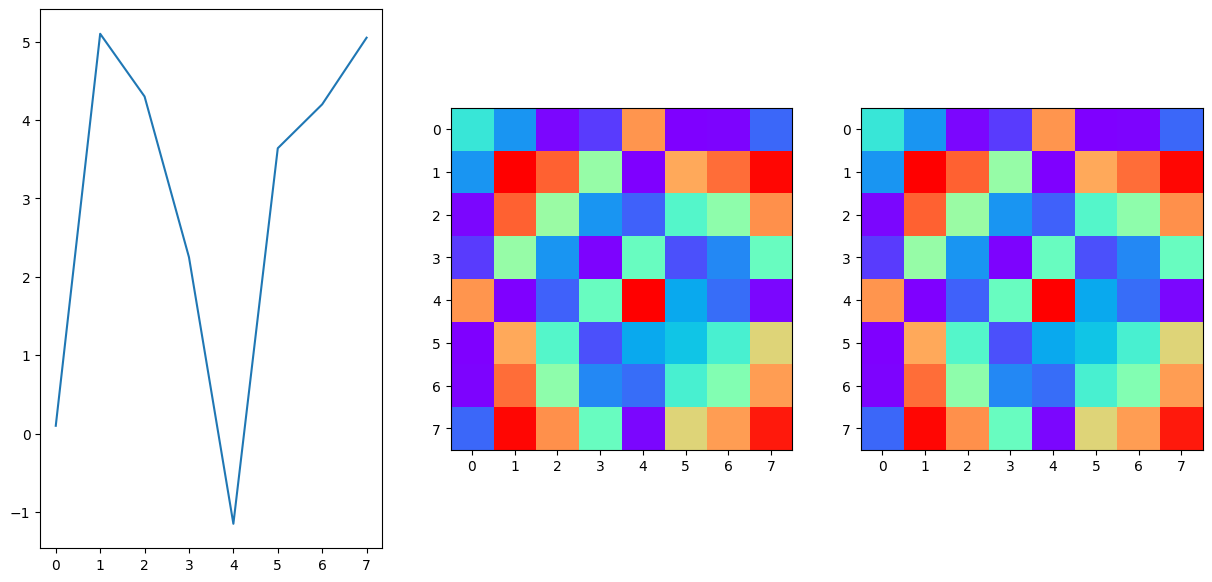

In [21]:
XX = np.array([0.1, 5.1, 4.3, 2.25, -1.15, 3.64, 4.2, 5.05])  # X_train[99,:] #
# Manual transformation
XX_norm = (XX - np.min(XX)) / (np.max(XX) - np.min(XX))
XX_norm = XX_norm * 2 - 1
print(XX_norm)
XX_arccos = np.arccos(XX_norm)
print(XX_arccos)
XX_arccos_m = np.add.outer(XX_arccos, XX_arccos)
GramAngular = np.cos(XX_arccos_m)
print(GramAngular)
# Using the library
GramAngular_pyts = transformer.transform(XX.reshape(1, -1))
# Show the results, compare the "from scratch" method with the pyts method
fig, ax = plt.subplots(1, 3, figsize=(15, 7), gridspec_kw={"width_ratios": [1, 1, 1]})
ax[0].plot(XX)
ax[1].imshow(GramAngular, cmap="rainbow")
ax[2].imshow(GramAngular_pyts[0], cmap="rainbow")